***As bibliotecas numpy, pandas, StandardScaler, load_model e matplotlib são importados para manipulação de dados, normalização, carregamento de modelos de Machine Learning (RNA), e plotagem de gráficos, respectivamente. warnings.filterwarnings("ignore") suprime avisos desnecessários.***

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

***A classe PID define um controlador PID, que ajusta a variável de controle com base no erro entre a medida atual e o valor desejado (setpoint). O construtor inicializa os ganhos e outras variáveis.***

***O método calcular é responsável por calcular a ação de controle aplicando os termos P, I e D do controlador PID.***

In [2]:
class PID:
    def __init__(self, Kp, Ki, Kd, setpoint):
        """
        Inicializa o controlador PID com os parâmetros fornecidos.

        :param Kp: Ganho Proporcional
        :param Ki: Ganho Integral
        :param Kd: Ganho Derivativo
        :param setpoint: Valor desejado para a saída
        """
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.setpoint = setpoint
        self.erro_anterior = 0
        self.integral = 0

    def calcular(self, medida, dt):
        """
        Calcula a ação de controle com base na medida atual.

        :param medida: Valor atual da saída medida
        :param dt: Intervalo de tempo
        :return: Ação de controle
        """
        erro = self.setpoint - medida
        self.integral += erro * dt
        derivada = (erro - self.erro_anterior) / dt if dt > 0 else 0
        self.erro_anterior = erro
        return self.Kp * erro + self.Ki * self.integral + self.Kd * derivada

***Carrega um modelo de Rede Neural Artificial (RNA) salvo no arquivo 'Modelo_AI_v1.h5', o arquivo de dados em formato Excel, remove algumas colunas indesejadas e verifica se o número de colunas restantes é o esperado***

***Normaliza os dados de entrada utilizando StandardScaler para ajustar a escala dos dados com base nas características do conjunto de treinamento.***

In [3]:
modelo_path = 'Modelo_AI_v1.h5'  

model = load_model(modelo_path)
print(f'Modelo carregado com sucesso de {modelo_path}.')    

file_path = r'DadosTratados.xlsx'  # Atenção em colocar o caminho correto

data = pd.read_excel(file_path)
print(f'Dados carregados com sucesso de {file_path}.')

X = data.drop(columns=['Timestamp', 'PT_4A', 'PT_3B', 'PT_6A', 'FT_2B',
                        'FT_4B', 'FT_5A', 'CV_4A_READ', 'PT_1A', 'FT_2A'])

if X.shape[1] != 13:
    print(f'Número de colunas selecionadas para entrada é {X.shape[1]}, esperado 13.')

scaler = StandardScaler()
scaler.fit(X)  

Modelo carregado com sucesso de Modelo_AI_v1.h5.
Dados carregados com sucesso de DadosTratados.xlsx.


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


***Define um valor de setpoint (5.0) e inicializa o controlador PID com ganhos P, I e D.***

***Define o intervalo de tempo dt e o número de passos num_steps para a simulação, além de variáveis para armazenar o histórico de setpoints, saídas e controles. entrada_atual é a primeira amostra dos dados de entrada.***

In [4]:
setpoint = 5.0  # Defina aqui o valor desejado para a saída
pid = PID(Kp=1, Ki=0.1, Kd=0.05, setpoint=setpoint)
print('Controlador PID inicializado.')

dt = 1.0  
num_steps = 1200  
historico_setpoint = []
historico_saida = []
historico_controle = []
entrada_atual = X.iloc[0].values.copy()
print('Entrada inicial definida a partir dos dados de treinamento.')

Controlador PID inicializado.
Entrada inicial definida a partir dos dados de treinamento.


***Itera por num_steps, ajusta o setpoint no step 400 e 800 para testar a resposta do sistema, escalona a entrada e faz previsões com o modelo carregado. A ação de controle é calculada e aplicada à entrada. Há um saturador para limitar a variável de controle.***

In [5]:
for passo in range(num_steps):
    if passo == 400 : 
        setpoint = 6.0
        pid = PID(Kp=1, Ki=0.1, Kd=0.05, setpoint=setpoint)

    if passo == 800 : 
        setpoint = 4.0
        pid = PID(Kp=1, Ki=0.1, Kd=0.05, setpoint=setpoint)

    entrada_scaled = scaler.transform([entrada_atual])

    saida_predita = model.predict(entrada_scaled)[0][0]

    historico_setpoint.append(setpoint)
    historico_saida.append(saida_predita)

    controle = pid.calcular(saida_predita, dt)
    historico_controle.append(controle)
    
    entrada_atual[0] += controle 
    
    entrada_atual[0] = np.clip(entrada_atual[0], 0, 100) 
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━

***Plota os resultados da simulação (setpoint, saída predita e controle) ao longo do tempo, para a análise do comportamento do sistema controlado.***

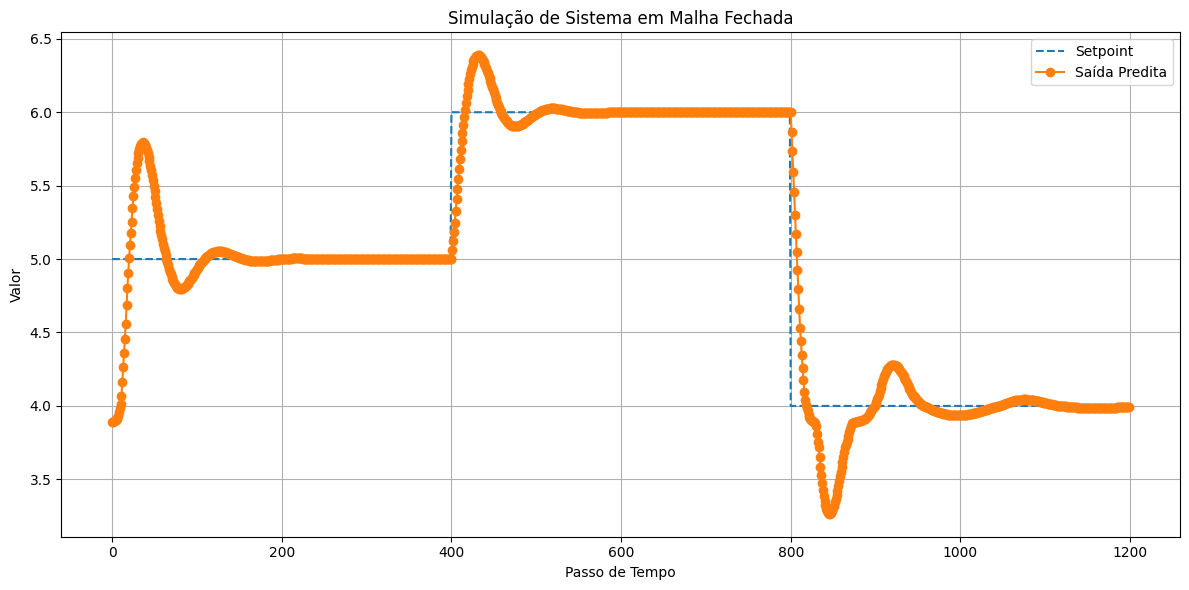

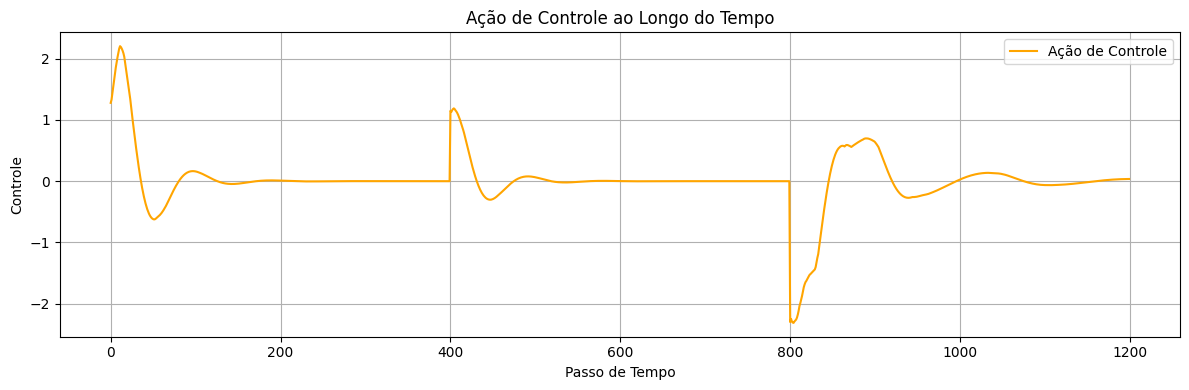

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(historico_setpoint, label='Setpoint', linestyle='--')
plt.plot(historico_saida, label='Saída Predita', marker='o')
plt.xlabel('Passo de Tempo')
plt.ylabel('Valor')
plt.title('Simulação de Sistema em Malha Fechada')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(historico_controle, label='Ação de Controle', color='orange')
plt.xlabel('Passo de Tempo')
plt.ylabel('Controle')
plt.title('Ação de Controle ao Longo do Tempo')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()